# ex014_Xie2015_B1

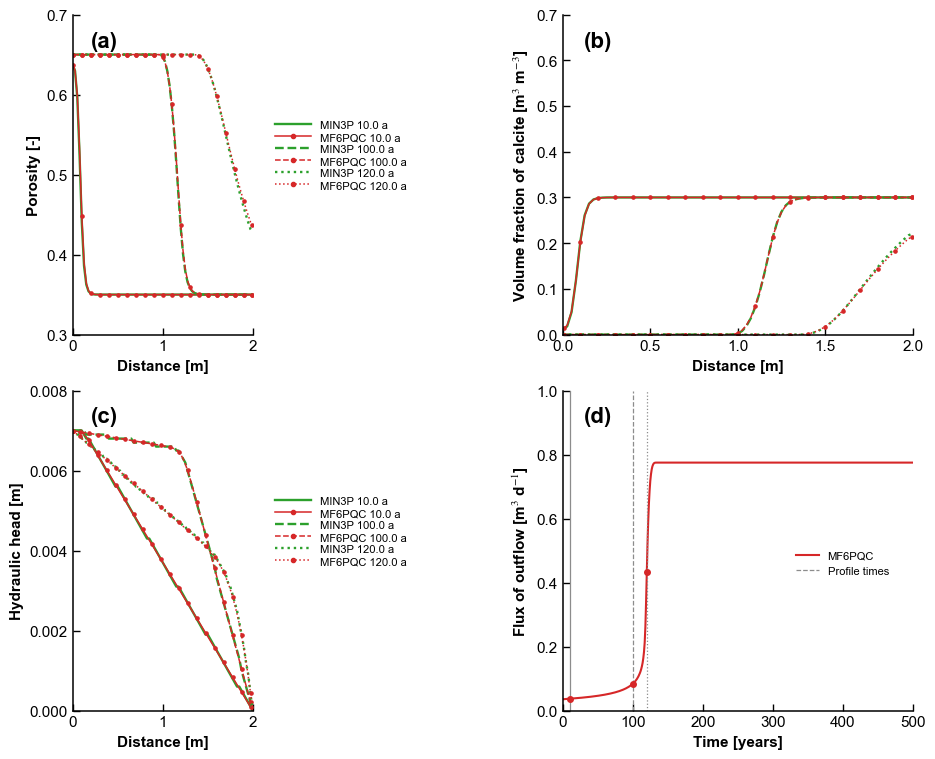

In [1]:
import pandas as pd
from IPython.display import display

comparison_rows = []
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd()
sys.path.insert(0, str(CASE_DIR.parents[1]))
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"
import flopy

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "mathtext.fontset": "stix",
    }
)
REFERENCE_FILE = INPUT_DIR / "MIN3P_results.csv"
PROFILE_YEARS = (10, 100, 120)
LENGTH = 2.0
from examples.ex014_Xie2015_B1.run import CALCITE_MOLAR_VOLUME

results = np.load(OUTPUT_DIR / "results.npy")
headings = (OUTPUT_DIR / "results_headings.txt").read_text(encoding="utf-8-sig").splitlines()
result_times = np.load(OUTPUT_DIR / "results_times.npy")
porosity = np.load(OUTPUT_DIR / "results_porosity.npy")
permeability = np.load(OUTPUT_DIR / "results_K.npy")
reference = pd.read_csv(REFERENCE_FILE)
sim = flopy.mf6.MFSimulation.load(sim_ws=str(SIMULATION_DIR), sim_name="model", verbosity_level=0)
years = result_times / 365.0
SIMULATION_YEARS = float(years[-1])
head_file = flopy.utils.HeadFile(str(SIMULATION_DIR / "gwf_model.hds"))
delr_mf6 = sim.get_model("gwf_model").dis.delr.array.ravel()
x_mf6 = np.cumsum(delr_mf6) - 0.5 * delr_mf6
x_min3p = np.linspace(0.0, LENGTH, len(reference))
head_times = np.asarray(head_file.get_times()) / 365.0
head_kstpkper = head_file.get_kstpkper()


def nearest_index(values, target):
    return int(np.abs(np.asarray(values) - target).argmin())


def profile_at_year(array, year, *, has_initial_state=False):
    index = nearest_index(years, year)
    return array[index if has_initial_state else index - 1]


head_profiles = {
    year: head_file.get_data(kstpkper=head_kstpkper[nearest_index(head_times, year)])[0, 0]
    for year in PROFILE_YEARS
}
gwf = sim.get_model("gwf_model")
left_head = float(gwf.get_package("bushui").stress_period_data.get_data(0)["bhead"][0])
right_head = float(gwf.get_package("ghb_right").stress_period_data.get_data(0)["bhead"][0])
head_x = np.r_[0.0, x_mf6, LENGTH]
head_curves = {year: np.r_[left_head, values, right_head] for year, values in head_profiles.items()}
calcite_index = headings.index("Calcite")


def calcite_profile_at_year(year):
    index = np.flatnonzero(np.isclose(years, year, rtol=0.0, atol=1e-07)).item()
    return results[index, calcite_index] * CALCITE_MOLAR_VOLUME


for year in PROFILE_YEARS:
    profiles = {
        "Porosity": porosity[nearest_index(years, year)],
        "Calcite": calcite_profile_at_year(year),
        "Hydraulic head": head_curves[year],
    }
    for name, values in profiles.items():
        coordinates = head_x if name == "Hydraulic head" else x_mf6
        error = np.interp(x_min3p, coordinates, values) - reference[f"{name} {year}years"]
        comparison_rows.append(
            {
                "Variable": name,
                "Time (yr)": year,
                "RMSE": np.sqrt(np.mean(error**2)),
                "Max abs": np.max(np.abs(error)),
            }
        )
gwf = sim.get_model("gwf_model")
budget_file = flopy.utils.CellBudgetFile(str(SIMULATION_DIR / "gwf_model.bud"))
budget_times = np.asarray(budget_file.get_times())
saved_outflow_flux = np.empty(len(years))
for index, days in enumerate(result_times[1:], start=1):
    native_time = budget_times[nearest_index(budget_times, days)]
    records = budget_file.get_data(totim=native_time, text="GHB", paknam2="GHB_RIGHT")
    saved_outflow_flux[index] = -records[0]["q"].sum()
budget_file.close()
saved_outflow_flux[0] = 0.007 / np.sum(delr_mf6 / permeability[0])
flux_years = np.unique(np.r_[np.arange(np.floor(SIMULATION_YEARS) + 1), SIMULATION_YEARS])
outflow_flux = np.interp(flux_years, years, saved_outflow_flux)
profile_flux = {year: saved_outflow_flux[nearest_index(years, year)] for year in PROFILE_YEARS}
styles = {10: "-", 100: "--", 120: ":"}
fig = plt.figure(figsize=(10.0, 8.0), facecolor="white")
axes = np.array(
    [
        [fig.add_axes((0.09, 0.55, 0.18, 0.4)), fig.add_axes((0.58, 0.55, 0.35, 0.4))],
        [fig.add_axes((0.09, 0.08, 0.18, 0.4)), fig.add_axes((0.58, 0.08, 0.35, 0.4))],
    ]
)
ax = axes[0, 0]
for year, style in styles.items():
    ax.plot(x_min3p, reference[f"Porosity {year}years"], color="tab:green", ls=style, lw=1.7)
    ax.plot(
        x_mf6,
        profile_at_year(porosity, year, has_initial_state=True),
        color="tab:red",
        ls=style,
        lw=1.1,
        marker="o",
        ms=2.3,
        markevery=4,
    )
ax.set(xlim=(0, LENGTH), ylim=(0.3, 0.7), xlabel="Distance [m]", ylabel="Porosity [-]")
ax.set_yticks(np.arange(0.3, 0.71, 0.1))
ax.text(0.1, 0.95, "(a)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
ax = axes[0, 1]
for year, style in styles.items():
    ax.plot(x_min3p, reference[f"Calcite {year}years"], color="tab:green", ls=style, lw=1.7)
    ax.plot(
        x_mf6,
        calcite_profile_at_year(year),
        color="tab:red",
        ls=style,
        lw=1.1,
        marker="o",
        ms=2.3,
        markevery=4,
    )
ax.set(
    xlim=(0, LENGTH),
    ylim=(0, 0.7),
    xlabel="Distance [m]",
    ylabel="Volume fraction of calcite [m$^3$ m$^{-3}$]",
)
ax.set_yticks(np.arange(0.0, 0.71, 0.1))
ax.text(0.06, 0.95, "(b)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
ax = axes[1, 0]
for year, style in styles.items():
    ax.plot(x_min3p, reference[f"Hydraulic head {year}years"], color="tab:green", ls=style, lw=1.7)
    ax.plot(
        head_x,
        head_curves[year],
        color="tab:red",
        ls=style,
        lw=1.1,
        marker="o",
        ms=2.3,
        markevery=4,
    )
ax.set(xlim=(0, LENGTH), ylim=(0, 0.008), xlabel="Distance [m]", ylabel="Hydraulic head [m]")
ax.set_yticks(np.arange(0.0, 0.0081, 0.002))
ax.text(0.1, 0.95, "(c)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
ax = axes[1, 1]
ax.plot(flux_years, outflow_flux, color="tab:red", lw=1.5, label="MF6PQC")
for year, style in styles.items():
    ax.axvline(year, color="0.55", ls=style, lw=0.9)
    if year in profile_flux:
        ax.plot(year, profile_flux[year], "o", color="tab:red", ms=4)
ax.set(
    xlim=(0, SIMULATION_YEARS),
    ylim=(0, 1.0),
    xlabel="Time [years]",
    ylabel="Flux of outflow [m$^3$ d$^{-1}$]",
)
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.text(0.06, 0.95, "(d)", transform=ax.transAxes, va="top", fontsize=16, fontweight="bold")
for ax in axes.flat:
    ax.tick_params(direction="in", length=5, width=1.0, top=False, right=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)
    ax.xaxis.label.set_fontweight("bold")
    ax.yaxis.label.set_fontweight("bold")
from matplotlib.lines import Line2D

legend_handles = [
    item
    for year, style in styles.items()
    for item in (
        Line2D([], [], color="tab:green", ls=style, lw=1.7, label=f"MIN3P {year:.1f} a"),
        Line2D(
            [],
            [],
            color="tab:red",
            ls=style,
            marker="o",
            lw=1.1,
            ms=3,
            label=f"MF6PQC {year:.1f} a",
        ),
    )
]
for ax in (axes[0, 0], axes[1, 0]):
    ax.legend(
        handles=legend_handles,
        frameon=False,
        fontsize=8,
        handlelength=3.2,
        loc="center left",
        bbox_to_anchor=(1.1, 0.56),
        borderaxespad=0.0,
        labelspacing=0.18,
    )
axes[1, 1].legend(
    handles=[
        Line2D([], [], color="tab:red", lw=1.5, label="MF6PQC"),
        Line2D([], [], color="0.55", ls="--", lw=0.9, label="Profile times"),
    ],
    frameon=False,
    fontsize=8,
    loc="center right",
    bbox_to_anchor=(0.96, 0.46),
)
fig.savefig(OUTPUT_DIR / "comparison.png", dpi=180, bbox_inches="tight")
plt.show()
comparison = pd.DataFrame(comparison_rows)
comparison = comparison.pivot(
    index="Variable", columns="Time (yr)", values=["RMSE", "Max abs"]
).reindex(comparison["Variable"].drop_duplicates())
display(
    comparison.style.format("{:.6g}").format_index("{:.6g}", axis=1, level=1).set_uuid("ex014_1")
)
head_file.close()